# F9 — Cash waterfalls, reserves and investor returns

Operating cash is not automatically available to investors. Loan agreements can require interest payments, principal repayments and reserve funding before owners receive anything. This agreed order of payments is called a **cash waterfall**.

Read F4 and F7 first. We return to the business that rents computer time and sells it. It owns no hardware to sell, so we do not add F8's sale money.

All rules are **hypothetical**. We owe USD 100,000. The loan charges 12% annual interest divided into monthly charges, and asks for USD 4,000 of principal each month for 25 months. A **cash sweep** uses some spare cash to repay principal early. That reduces later interest.

Owners invest USD 30,000. Of this, USD 2,000 is placed in a **restricted reserve**, cash set aside for specified uses. The other USD 28,000 has already been used in the business. There is no other opening cash. Owner investment is also called **equity**.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.waterfalls import build_cash_waterfall, equity_return_summary

assumptions = dict(
    cash_after_operations_usd=(10_000, 10_000, 3_000) + (10_000,) * 22,
    initial_debt_usd=100_000,
    nominal_annual_interest_rate=0.12,
    scheduled_principal_usd=(4_000,) * 25,
    opening_reserve_usd=2_000,
    reserve_target_usd=6_000,
    sweep_fraction=0.50,
)
equity_invested_usd = 30_000
print(
    "Interest → scheduled principal → reserve top-up → extra principal sweep → permitted equity distribution"
)

Interest → scheduled principal → reserve top-up → extra principal sweep → permitted equity distribution


## Allocate the first month’s cash

We have USD 10,000 left after running costs. Follow the agreed order:

1. Pay USD 1,000 interest.
2. Repay USD 4,000 of the borrowed principal.
3. Add USD 4,000 to the reserve, bringing it from USD 2,000 to USD 6,000.
4. Split the remaining USD 1,000 equally: USD 500 of extra loan repayment and USD 500 for the owners.

Money paid to owners is a **distribution**. Moving money into the reserve is saving cash, not paying a running cost. Repaying principal reduces debt. These are reasons the business's operating profit is not the same as money owners can take home.

In [3]:
after_debt_usd = 10_000 - 1_000 - 4_000
topup_usd = 6_000 - 2_000
remaining_usd = after_debt_usd - topup_usd
sweep_usd = remaining_usd * 0.50
distribution_usd = remaining_usd - sweep_usd
closing_debt_usd = 100_000 - 4_000 - sweep_usd
show_finance_table(
    ["First-month allocation", "USD"],
    [
        ["Interest", 1_000],
        ["Scheduled principal", 4_000],
        ["Reserve top-up", topup_usd],
        ["Extra principal sweep", sweep_usd],
        ["Equity distribution", distribution_usd],
        ["Closing debt", closing_debt_usd],
    ],
)

| First-month allocation | USD |
| --- | --- |
| Interest | 1,000.00 |
| Scheduled principal | 4,000.00 |
| Reserve top-up | 4,000.00 |
| Extra principal sweep | 500.00 |
| Equity distribution | 500.00 |
| Closing debt | 95,500.00 |

Owners receive only **USD 500** in month 1. Debt falls to **USD 95,500**.

Next month's interest is **USD 955**, or 1% of that smaller debt. Charging USD 1,000 again would ignore the repayment.

## Track debt, reserves and unpaid obligations

Cash after running costs is USD 10,000 in months 1–2, only USD 3,000 in month 3, then USD 10,000 for the next 22 months.

When cash is short, use available ordinary cash, then reserve cash. If that is still insufficient, record what remains unpaid. An overdue amount is called **arrears**. Overdue interest is paid before new interest; overdue principal before new principal.

Unpaid interest does not itself earn interest here. Principal still owed does earn ordinary loan interest, including principal we should already have repaid. We never repay more principal than remains.

In [4]:
baseline = build_cash_waterfall(**assumptions)


def ledger(rows):
    selected = sorted({0, 1, 2, len(rows) - 1})
    show_finance_table(
        [
            "Month",
            "Interest paid (USD)",
            "Principal paid (USD)",
            "Sweep (USD)",
            "Reserve (USD)",
            "Equity paid (USD)",
            "Debt (USD)",
        ],
        [
            [
                i + 1,
                rows[i].interest_paid_usd,
                rows[i].principal_paid_usd,
                rows[i].sweep_usd,
                rows[i].closing.reserve_usd,
                rows[i].distribution_usd,
                rows[i].closing.debt_usd,
            ]
            for i in selected
        ],
    )


ledger(baseline)

| Month | Interest paid (USD) | Principal paid (USD) | Sweep (USD) | Reserve (USD) | Equity paid (USD) | Debt (USD) |
| --- | --- | --- | --- | --- | --- | --- |
| 1.00 | 1,000.00 | 4,000.00 | 500.00 | 6,000.00 | 500.00 | 95,500.00 |
| 2.00 | 955.00 | 4,000.00 | 2,522.50 | 6,000.00 | 2,522.50 | 88,977.50 |
| 3.00 | 889.77 | 4,000.00 | 0.00 | 4,110.23 | 0.00 | 84,977.50 |
| 25.00 | 0.00 | 0.00 | 0.00 | 0.00 | 10,000.00 | 0.00 |

The short table shows the first three months and the final months. The full schedule remains in `baseline`. It keeps ordinary cash, reserve cash and unpaid bills separate. Additional owner contributions are not assumed.

## Read the payment chart

Each month's bar shows interest, principal repayments, reserve savings and owner distributions. In a weak month, payments can exceed that month's new cash because the reserve helps. At the end, releasing saved reserve money can also increase distributions.

So read the reserve balance with the chart. The bars are cash uses, not operating profit.

A bigger reserve keeps more cash saved. A bigger sweep repays debt faster. Change these inputs in the cells or use the optional controls, which keep their own starting values.

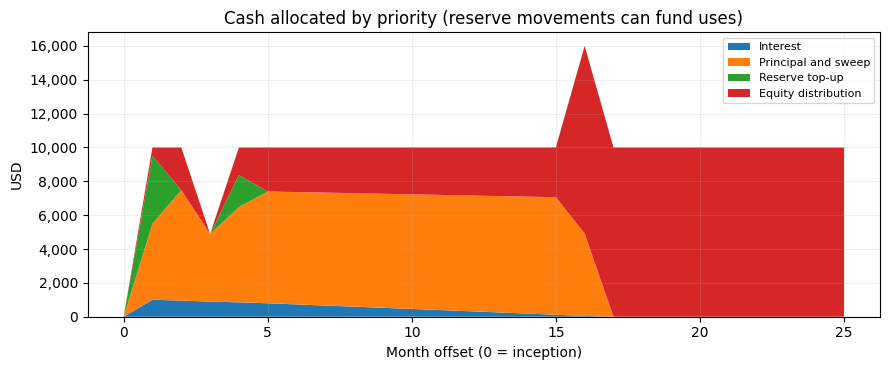

In [5]:
display(
    plot_finance_series(
        {
            "Interest": [0] + [r.interest_paid_usd for r in baseline],
            "Principal and sweep": [0]
            + [r.principal_paid_usd + r.sweep_usd for r in baseline],
            "Reserve top-up": [0] + [r.reserve_topup_usd for r in baseline],
            "Equity distribution": [0] + [r.distribution_usd for r in baseline],
        },
        title="Cash allocated by priority (reserve movements can fund uses)",
        stacked=True,
    )
)


def waterfall_explorer(values, source=assumptions.copy()):
    from liquid_compute.waterfalls import build_cash_waterfall

    rows = build_cash_waterfall(
        **(
            source
            | dict(
                reserve_target_usd=values["Reserve target (USD)"],
                sweep_fraction=values["Sweep fraction"],
            )
        )
    )
    return {
        "Interest": [0] + [r.interest_paid_usd for r in rows],
        "Principal and sweep": [0] + [r.principal_paid_usd + r.sweep_usd for r in rows],
        "Reserve top-up": [0] + [r.reserve_topup_usd for r in rows],
        "Equity distribution": [0] + [r.distribution_usd for r in rows],
    }


explore_finance_series(
    {"Reserve target (USD)": 6_000.0, "Sweep fraction": 0.50},
    waterfall_explorer,
    title="Allocation priorities",
    stacked=True,
);

Reserve cash can help pay a weak month's bills and be topped up later. Transfers into and out of the reserve change the location and availability of cash; they do not create operating expenses or sales revenue.

We release any remaining reserve only after all debt and overdue amounts are cleared.

## Experiment 1 — A weak third month

Compare USD 3,000 in month 3 with USD 10,000 in every month. Both paths enter month 3 with the same debt and reserve.

The weak month first pays interest. The reserve then helps pay principal. Owners must wait behind those bills.

In [6]:
strong = build_cash_waterfall(
    **(assumptions | dict(cash_after_operations_usd=(10_000,) * 25))
)
show_finance_table(
    [
        "Third-month case",
        "New cash (USD)",
        "Reserve drawn (USD)",
        "Unpaid interest (USD)",
        "Unpaid principal (USD)",
        "Distribution (USD)",
    ],
    [
        [
            name,
            rows[2].cash_available_usd,
            rows[2].reserve_draw_usd,
            rows[2].closing.interest_arrears_usd,
            rows[2].closing.principal_arrears_usd,
            rows[2].distribution_usd,
        ]
        for name, rows in {"Strong": strong, "Weak": baseline}.items()
    ],
)

| Third-month case | New cash (USD) | Reserve drawn (USD) | Unpaid interest (USD) | Unpaid principal (USD) | Distribution (USD) |
| --- | --- | --- | --- | --- | --- |
| Strong | 10,000.00 | 0.00 | 0.00 | 0.00 | 2,555.11 |
| Weak | 3,000.00 | 1,889.78 | 0.00 | 0.00 | 0.00 |

The reserve covers this particular shortage. Owners get **no distribution in month 3**.

A worse shortage, or several weak months, could empty the reserve. If bills remain unpaid, we carry them forward and stop owner distributions. No additional borrowing is assumed to cover the shortfall.

## Experiment 2 — Repay extra debt faster

Compare sweeps of 0%, 50% and 100% of remaining cash, keeping the original weak month.

All paths start with the same loan, reserve and operating cash. A bigger sweep repays debt sooner and reduces future interest. It also leaves less for owners to take out while debt remains.

In [7]:
sweep_cases = {
    f"{int(fraction * 100)}% sweep": build_cash_waterfall(
        **(assumptions | dict(sweep_fraction=fraction))
    )
    for fraction in (0, 0.5, 1)
}


def summary(cases):
    rows = []
    for name, schedule in cases.items():
        returns = equity_return_summary(
            equity_investments_usd=[equity_invested_usd],
            equity_distributions_usd=[r.distribution_usd for r in schedule],
        )
        rows.append(
            [
                name,
                sum(r.interest_paid_usd for r in schedule),
                returns.returned_usd,
                returns.net_gain_usd,
                returns.moic,
                schedule[-1].closing.debt_usd,
            ]
        )
    show_finance_table(
        [
            "Case",
            "Interest paid (USD)",
            "Equity returned (USD)",
            "Net gain (USD)",
            "MOIC (multiple)",
            "Ending debt (USD)",
        ],
        rows,
    )


summary(sweep_cases)

| Case | Interest paid (USD) | Equity returned (USD) | Net gain (USD) | MOIC (multiple) | Ending debt (USD) |
| --- | --- | --- | --- | --- | --- |
| 0% sweep | 13,000.00 | 132,000.00 | 102,000.00 | 4.40 | 0.00 |
| 50% sweep | 8,784.61 | 136,215.39 | 106,215.39 | 4.54 | 0.00 |
| 100% sweep | 6,955.81 | 138,044.19 | 108,044.19 | 4.60 | 0.00 |

The sweep changes both when owners receive money and how much interest the business pays.

To compare total money returned, divide owner distributions by owner investment. This is **MOIC**, or “multiple of invested capital.” A result of 2 means USD 2 returned for every USD 1 put in. A result below 1 means some invested money was lost.

MOIC does not say how quickly money came back. It is not a yearly return. We do not calculate an annual investment return here.

## Experiment 3 — Restrict investor distributions

Now apply a contractual restriction that blocks distributions through month 24 and permits them again in month 25. Retain unrestricted cash in the business, where it can fund later obligations and permitted extra repayments. “Unrestricted” means it is not held in the designated reserve.

This rule locks owner payouts; it does not separately forbid paying the loan early.

In [8]:
locked = build_cash_waterfall(**assumptions, distribution_locks=(True,) * 24 + (False,))
ledger(locked)
summary({"Permitted distributions": baseline, "Locked until month 25": locked})

| Month | Interest paid (USD) | Principal paid (USD) | Sweep (USD) | Reserve (USD) | Equity paid (USD) | Debt (USD) |
| --- | --- | --- | --- | --- | --- | --- |
| 1.00 | 1,000.00 | 4,000.00 | 500.00 | 6,000.00 | 0.00 | 95,500.00 |
| 2.00 | 955.00 | 4,000.00 | 2,772.50 | 6,000.00 | 0.00 | 88,727.50 |
| 3.00 | 887.27 | 4,000.00 | 442.61 | 6,000.00 | 0.00 | 84,284.89 |
| 25.00 | 0.00 | 0.00 | 0.00 | 0.00 | 137,546.00 | 0.00 |

| Case | Interest paid (USD) | Equity returned (USD) | Net gain (USD) | MOIC (multiple) | Ending debt (USD) |
| --- | --- | --- | --- | --- | --- |
| Permitted distributions | 8,784.61 | 136,215.39 | 106,215.39 | 4.54 | 0.00 |
| Locked until month 25 | 7,454.00 | 137,546.00 | 107,546.00 | 4.58 | 0.00 |

Owners receive nothing during the first 24 months. The retained cash remains available for the uses permitted by the agreement.

When payouts are allowed again, owners can receive available ordinary cash after the required bills. If debt or overdue bills remain at the end, the schedule shows them. No unsupported final distribution is added.

Count the opening reserve once in the owner's initial investment. Later top-ups come from business cash. Count a reserve release once when it reaches the owners.

Investor results use actual owner contributions and payouts. Borrowed money and accounting book value are not owner returns. If a later example sells equipment, count F8's sale cash only once.

In [9]:
returns = equity_return_summary(
    equity_investments_usd=[30_000],
    equity_distributions_usd=[r.distribution_usd for r in baseline],
)
show_finance_table(
    ["Equity measure", "Value"],
    [
        ["Cash invested (USD)", returns.invested_usd],
        ["Cash returned (USD)", returns.returned_usd],
        ["Net gain (USD)", returns.net_gain_usd],
        ["MOIC (not annual return)", returns.moic],
    ],
)

| Equity measure | Value |
| --- | --- |
| Cash invested (USD) | 30,000.00 |
| Cash returned (USD) | 136,215.39 |
| Net gain (USD) | 106,215.39 |
| MOIC (not annual return) | 4.54 |

The baseline returns **USD 136,215.39** on USD 30,000 invested. That is **USD 106,215.39 more than was put in**, or **4.5405 times** the investment over 25 months. It is not a yearly return.

This ends the financing track. **Next: C1, structure and stress-test a compute transaction**, after completing its market-risk prerequisites too.

The [World Bank's transaction discussion](https://ppp.worldbank.org/financing/issues-in-project-financed-transactions) describes reserves, extra debt repayments and payout restrictions. Our precise order and amounts are hypothetical.

If running costs exceed receipts, that operating shortage is paid before debt. We leave out taxes, special preferred-investor payout rules and unplanned owner contributions.